In [1]:
"""
=====================================================================================================================
ICELLI 2026: TIME SERIES ANALYSIS IN SPACE PHYSICS: A PRACTICAL PYTHON WORKFLOW FOR IONOSPHERIC AND GEOMAGNETIC DATA
=====================================================================================================================

Presenter          : Bello Saeed Abioye
Affiliation        : Department of Physics, University of Ilorin
Email              : bello.sa@unilorin.edu.ng
ORCiD              : https://orcid.org/0000-0002-5527-1110

Key Learning Resources:
  - Python Official Documentation : https://www.python.org/
  - Pandas Getting Started Guides : https://pandas.pydata.org/docs/getting_started/intro_tutorials/index.html
  - Markdown Cheat Sheet Guide    : https://www.markdownguide.org/cheat-sheet/
  - DIDBase Data Portal           : https://giro.uml.edu/didbase/scaled.php

Station Data       : Ilorin Ionosonde, Nigeria (Station Code: IL008 | GEO: 8.5° N, 4.5° E)

Key Ionospheric Parameters:
  - Time     : Observation timestamp in UTC (ISO 8601 format)
  - CS       : Confidence Score (0 to 100) assigned by autoscaling (ARTIST)
  - foF2     : Critical frequency of the F2 layer (MHz), directly proportional to
               peak electron density: NmF2 (el/m³) ≈ 1.24e10 * (foF2 in MHz)²
  - hmF2     : Peak height of the F2 layer (km)
  - QD       : Qualifying and Descriptive letters / flags (e.g., '//', '---')
========================================================================================
"""

"\n=====================================================================================================================\nICELLI 2026: TIME SERIES ANALYSIS IN SPACE PHYSICS: A PRACTICAL PYTHON WORKFLOW FOR IONOSPHERIC AND GEOMAGNETIC DATA\n=====================================================================================================================\n\nPresenter          : Bello Saeed Abioye\nAffiliation        : Department of Physics, University of Ilorin\nEmail              : bello.sa@unilorin.edu.ng\nORCiD              : https://orcid.org/0000-0002-5527-1110\n\nKey Learning Resources:\n  - Python Official Documentation : https://www.python.org/\n  - Pandas Getting Started Guides : https://pandas.pydata.org/docs/getting_started/intro_tutorials/index.html\n  - Markdown Cheat Sheet Guide    : https://www.markdownguide.org/cheat-sheet/\n  - DIDBase Data Portal           : https://giro.uml.edu/didbase/scaled.php\n\nStation Data       : Ilorin Ionosonde, Nigeria (Station Code: IL008

# ICELLI 2026: Python for Ionospheric Data Analysis
**Presenter:** Bello Saeed Abioye  
**Affiliation:** Department of Physics, University of Ilorin | [bello.sa@unilorin.edu.ng](mailto:bello.sa@unilorin.edu.ng)  
**ORCiD:** [https://orcid.org/0000-0002-5527-1110](https://orcid.org/0000-0002-5527-1110)  

### 📚 Essential Reference Links:
- [Welcome to Python.org](https://www.python.org/)
- [Getting Started Tutorials — Pandas Documentation](https://pandas.pydata.org/docs/getting_started/intro_tutorials/index.html)
- [Markdown Cheat Sheet | Markdown Guide](https://www.markdownguide.org/cheat-sheet/)
- [DIDBase Ionogram-Scaled Characteristics (GIRO Data Center)](https://giro.uml.edu/didbase/scaled.php)

---

### Section 1: Importing Core Scientific Libraries
- **Pandas**: Tabular data manipulation, time-series indexing, CSV parsing.
- **NumPy**: High-performance numerical computations and linear regression fits.
- **Matplotlib**: 2D plotting, subplots, publication-quality figures.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional: Set a clean, modern aesthetic for all plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14

print("Libraries imported successfully!")

Libraries imported successfully!


### Section 2: Reading DIDBase / GIRO Ionospheric Data
Ionospheric data files from DIDBase typically have:
1. 20+ lines of license, station metadata, and header comments starting with `#`.
2. Whitespace separation (multiple spaces) rather than commas or tabs.
3. Missing values encoded as `---`.

We handle these using:
- `sep=r'\s+'` : Regular expression matching one or more whitespace characters.
- `skiprows=21` : Skips the 21 metadata comment lines.
- `names=...`   : Assigns explicit, clean column names.
- `na_values=['---']`: Automatically converts `---` missing value indicators to `NaN`.

In [3]:
# Define clean column names
columns = ['Time', 'CS', 'foF2', 'foF2_QD', 'hmF2', 'hmF2_QD']

# Load dataset
data_file = 'ILR_data.txt'
df = pd.read_csv(
    data_file,
    sep=r'\s+',
    skiprows=21,
    names=columns,
    na_values=['---']
)

print(df.head())

                       Time   CS   foF2 foF2_QD   hmF2 hmF2_QD
0  2010-03-26T16:45:00.000Z  100  8.775      //  376.2      //
1  2010-03-26T17:00:00.000Z  100  8.806      //  372.6      //
2  2010-03-26T17:15:00.000Z   50  6.863      //  288.5      //
3  2010-03-26T17:30:00.000Z   75  8.950      //  359.1      //
4  2010-03-26T17:45:00.000Z  100  9.050      //  357.9      //


In [4]:
# Convert Time string (e.g. '2010-03-26T16:45:00.000Z') to pandas Datetime objects
df['Time'] = pd.to_datetime(df['Time'])
print(df.dtypes)

Time       datetime64[ns, UTC]
CS                       int64
foF2                   float64
foF2_QD                 object
hmF2                   float64
hmF2_QD                 object
dtype: object


In [5]:
# Display initial summary
print("--- Data Summary ---")
print(f"Total records loaded: {len(df):,}")
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 Records:")
print(df.head())

--- Data Summary ---
Total records loaded: 18,148

Data Types:
Time       datetime64[ns, UTC]
CS                       int64
foF2                   float64
foF2_QD                 object
hmF2                   float64
hmF2_QD                 object
dtype: object

First 5 Records:
                       Time   CS   foF2 foF2_QD   hmF2 hmF2_QD
0 2010-03-26 16:45:00+00:00  100  8.775      //  376.2      //
1 2010-03-26 17:00:00+00:00  100  8.806      //  372.6      //
2 2010-03-26 17:15:00+00:00   50  6.863      //  288.5      //
3 2010-03-26 17:30:00+00:00   75  8.950      //  359.1      //
4 2010-03-26 17:45:00+00:00  100  9.050      //  357.9      //


### Section 3: Data Cleaning & Type Conversion
Even after specifying `na_values`, it is best practice to enforce numeric types
on physical parameters (`foF2` and `hmF2`) with `errors='coerce'`.
This safely converts any remaining unparsed characters into `NaN` (Not a Number).

In [6]:
# Enforce float conversion
df['foF2'] = pd.to_numeric(df['foF2'], errors='coerce')
df['hmF2'] = pd.to_numeric(df['hmF2'], errors='coerce')

print(df.dtypes)

Time       datetime64[ns, UTC]
CS                       int64
foF2                   float64
foF2_QD                 object
hmF2                   float64
hmF2_QD                 object
dtype: object


In [7]:
# Check missing value statistics
missing_foF2 = df['foF2'].isna().sum()
missing_hmF2 = df['hmF2'].isna().sum()
print(f"Missing foF2 values: {missing_foF2:,} ({missing_foF2/len(df)*100:.1f}%)")
print(f"Missing hmF2 values: {missing_hmF2:,} ({missing_hmF2/len(df)*100:.1f}%)")

# Summary statistics of physical parameters
print("\n--- Physical Characteristics Summary ---")
print(df[['foF2', 'hmF2', 'CS']].describe())

Missing foF2 values: 0 (0.0%)
Missing hmF2 values: 893 (4.9%)

--- Physical Characteristics Summary ---
               foF2          hmF2            CS
count  18148.000000  17255.000000  18148.000000
mean       6.635093    308.430669     75.988043
std        2.024548     46.511306     41.829731
min        1.250000    111.100000      0.000000
25%        5.400000    270.000000     50.000000
50%        7.050000    308.700000     75.000000
75%        8.100000    341.900000    100.000000
max       11.675000    659.300000    999.000000


### Section 4: Data Subsetting & Slicing (`iloc`, `loc`, & Date Ranges)
A crucial skill for ionospheric data analysis is filtering for specific days (e.g., geomagnetically quiet vs. disturbed storm periods).

- **`iloc`**: Integer position-based indexing (`df.iloc[row_idx, col_idx]`).
- **`loc`**: Label/Boolean condition indexing (`df.loc[condition, col_names]`).
- **Date Slicing**: Using `.between(start, end)` or setting `Time` as index.

In [8]:
# 1. Example of iloc: Extract first 5 rows and the first 3 columns
sample_iloc = df.iloc[0:5, [0, 1, 2]]
print("iloc sample (first 5 rows, first 3 cols):")
print(sample_iloc)

# 2. Example of loc: Filter high-confidence data (CS >= 80) where foF2 > 10 MHz
high_quality_peaks = df.loc[(df['CS'] >= 80) & (df['foF2'] > 10), ['Time', 'CS', 'foF2', 'hmF2']]
print(f"\nFound {len(high_quality_peaks)} records with CS >= 80 and foF2 > 10 MHz.")

# 3. Example of Date Filtering: Select a 3-day window for storm/quiet analysis
start_date = '2010-03-26'
end_date   = '2010-03-29'
event_df = df[df['Time'].between(start_date, end_date)].copy()
print(f"\nRecords selected for period {start_date} to {end_date}: {len(event_df):,}")

iloc sample (first 5 rows, first 3 cols):
                       Time   CS   foF2
0 2010-03-26 16:45:00+00:00  100  8.775
1 2010-03-26 17:00:00+00:00  100  8.806
2 2010-03-26 17:15:00+00:00   50  6.863
3 2010-03-26 17:30:00+00:00   75  8.950
4 2010-03-26 17:45:00+00:00  100  9.050

Found 244 records with CS >= 80 and foF2 > 10 MHz.

Records selected for period 2010-03-26 to 2010-03-29: 208


### Section 5: Basic Exploratory Visualization
Visualizing single parameters over time using pandas/matplotlib.

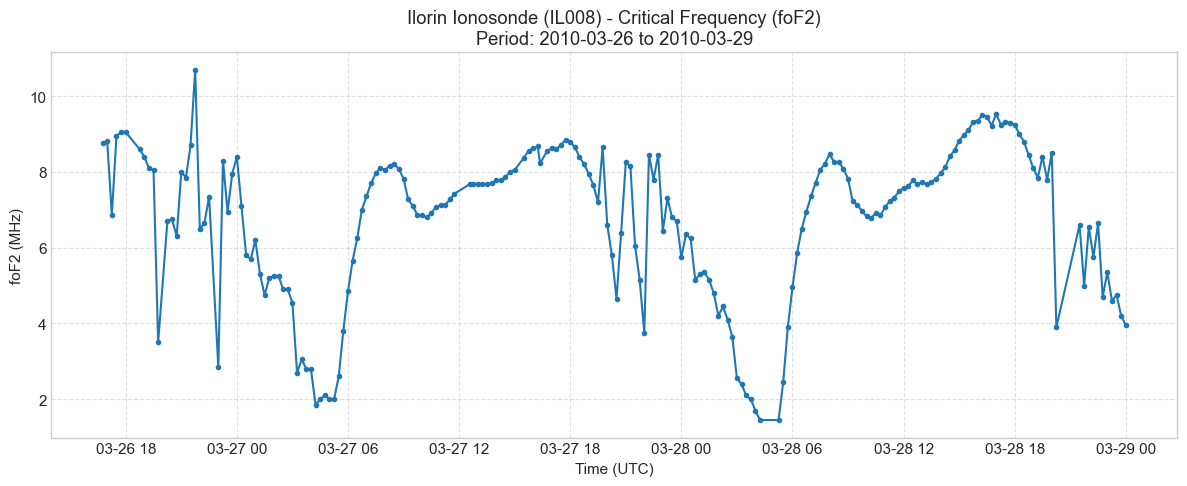

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(event_df['Time'], event_df['foF2'], color='tab:blue', linewidth=1.5, marker='o', markersize=3)
plt.title(f"Ilorin Ionosonde (IL008) - Critical Frequency (foF2)\nPeriod: {start_date} to {end_date}")
plt.xlabel("Time (UTC)")
plt.ylabel("foF2 (MHz)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Section 6: Advanced Subplots (Vertically Stacked with Shared Time Axis)
In Space Physics and Aeronomy, comparing critical frequency ($foF2$) and peak height ($hmF2$)
on aligned time scales allows quick identification of ionospheric dynamics (e.g., equatorial plasma fountain, pre-reversal enhancement, acoustic gravity waves).

Key Features:
- `plt.subplots(nrows=2, ncols=1, sharex=True)` : Aligns x-axes so zooming/panning is synchronized.

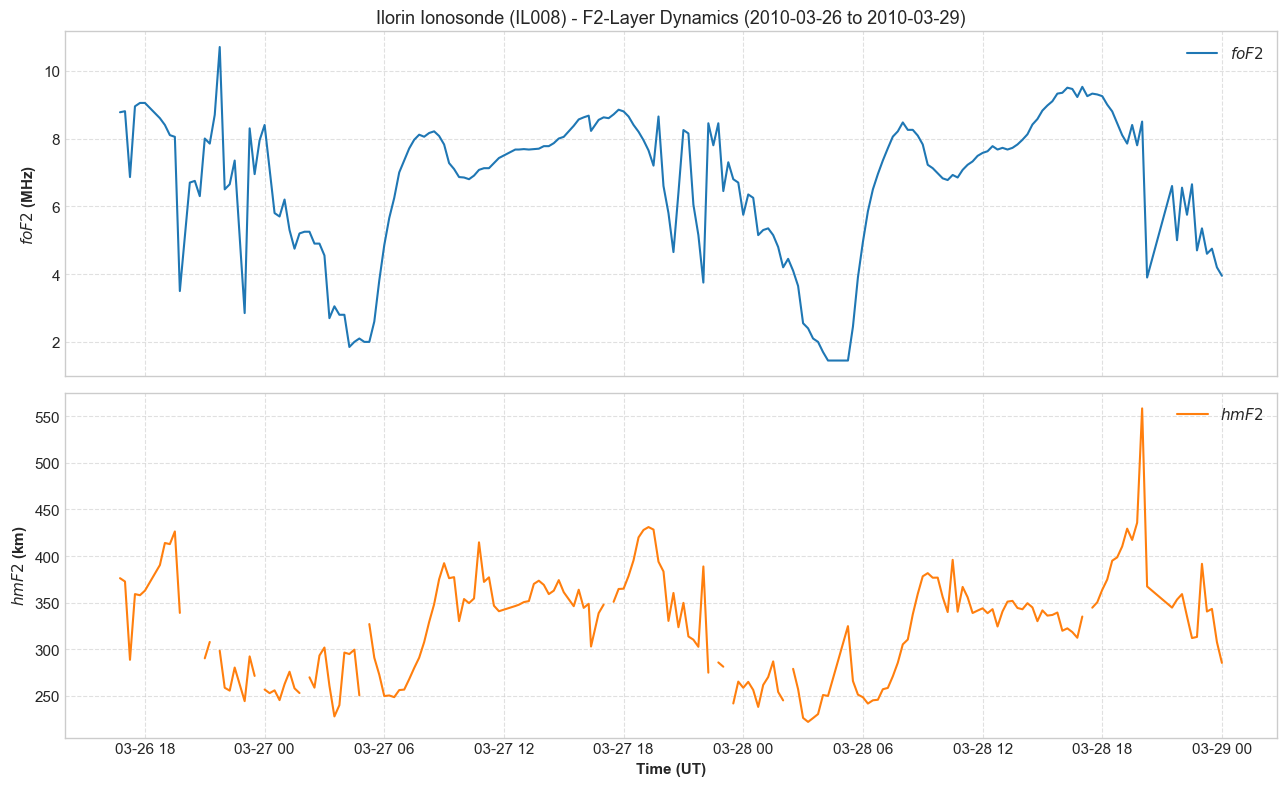

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(13, 8), sharex=True)

# Top Subplot: foF2
axes[0].plot(event_df['Time'], event_df['foF2'], color='tab:blue', lw=1.5, label=r'$foF2$')
axes[0].set_ylabel(r'$foF2$ (MHz)', fontweight='bold')
axes[0].set_title(f"Ilorin Ionosonde (IL008) - F2-Layer Dynamics ({start_date} to {end_date})", fontsize=13)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='upper right')

# Bottom Subplot: hmF2
axes[1].plot(event_df['Time'], event_df['hmF2'], color='tab:orange', lw=1.5, label=r'$hmF2$')
axes[1].set_xlabel("Time (UT)", fontweight='bold')
axes[1].set_ylabel(r'$hmF2$ (km)', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

### Section 7: Comprehensive 2×2 Multi-Panel Statistical Dashboard
A complete publication-ready 4-panel figure combining:
1. **Time-Series of foF2** (Critical Frequency)
2. **Histogram Distribution of foF2** (with statistical mean and median markers)
3. **Time-Series of hmF2** (Peak Height)
4. **Scatter Plot with Linear Regression Fit & Pearson Correlation ($r, R^2$)**

Visualization Concepts Demonstrated:
- **`tab:` Colors**: Modern colorblind-friendly Tableau palette.
- **`alpha`**: Controls opacity to reveal data density in scatter plots.
- **`bins`**: Controls histogram bucket resolution.
- **`np.polyfit()`**: Computes 1st-degree best fit line $y = mx + c$.
- **`Series.corr()`**: Computes Pearson correlation coefficient $r$.

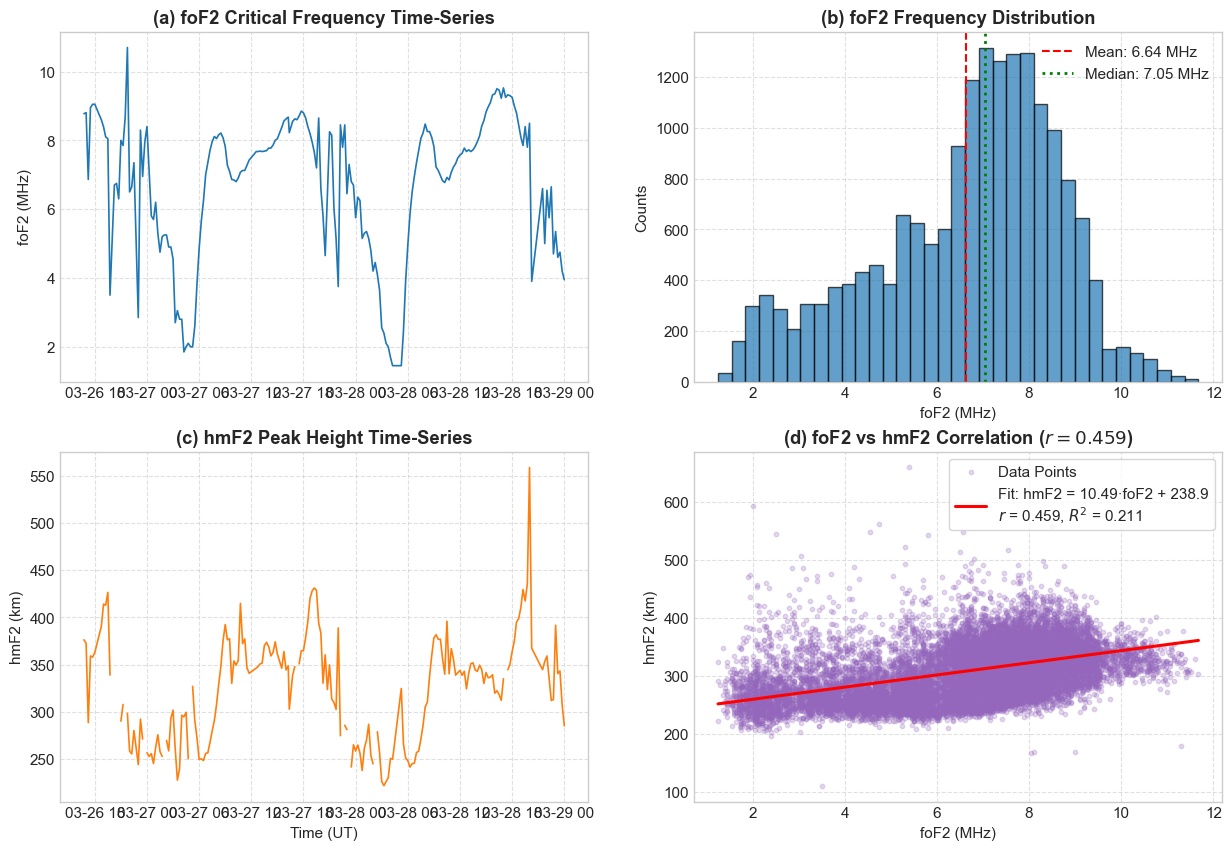

In [11]:
# Prepare figure layout
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

# -------------------------------------------------------------
# Panel 1 (Top-Left): Time-Series of foF2
# -------------------------------------------------------------
axes[0].plot(event_df['Time'], event_df['foF2'], color='tab:blue', lw=1.2)
axes[0].set_title("(a) foF2 Critical Frequency Time-Series", fontweight='bold')
axes[0].set_ylabel("foF2 (MHz)")
axes[0].grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------
# Panel 2 (Top-Right): Histogram Distribution of foF2
# -------------------------------------------------------------
valid_fof2 = df['foF2'].dropna()
mean_fof2 = valid_fof2.mean()
median_fof2 = valid_fof2.median()

axes[1].hist(valid_fof2, bins=35, color='tab:blue', edgecolor='black', alpha=0.7, density=False)
axes[1].axvline(mean_fof2, color='red', linestyle='--', lw=1.5, label=f'Mean: {mean_fof2:.2f} MHz')
axes[1].axvline(median_fof2, color='green', linestyle=':', lw=2, label=f'Median: {median_fof2:.2f} MHz')
axes[1].set_title("(b) foF2 Frequency Distribution", fontweight='bold')
axes[1].set_xlabel("foF2 (MHz)")
axes[1].set_ylabel("Counts")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# -------------------------------------------------------------
# Panel 3 (Bottom-Left): Time-Series of hmF2
# -------------------------------------------------------------
axes[2].plot(event_df['Time'], event_df['hmF2'], color='tab:orange', lw=1.2)
axes[2].set_title("(c) hmF2 Peak Height Time-Series", fontweight='bold')
axes[2].set_xlabel("Time (UT)")
axes[2].set_ylabel("hmF2 (km)")
axes[2].grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------
# Panel 4 (Bottom-Right): Scatter Plot & Linear Regression
# -------------------------------------------------------------
valid_pairs = df[['foF2', 'hmF2']].dropna()

# Statistical correlation & linear fit
r = valid_pairs['foF2'].corr(valid_pairs['hmF2'])
r2 = r ** 2
slope, intercept = np.polyfit(valid_pairs['foF2'], valid_pairs['hmF2'], deg=1)
x_fit = np.linspace(valid_pairs['foF2'].min(), valid_pairs['foF2'].max(), 100)
y_fit = slope * x_fit + intercept

# Scatter plot with transparency (alpha=0.25) to show density
axes[3].scatter(valid_pairs['foF2'], valid_pairs['hmF2'], color='tab:purple', alpha=0.25, s=10, label='Data Points')
axes[3].plot(x_fit, y_fit, color='red', lw=2.2,
             label=f'Fit: hmF2 = {slope:.2f}·foF2 + {intercept:.1f}\n$r$ = {r:.3f}, $R^2$ = {r2:.3f}')

axes[3].set_title(f"(d) foF2 vs hmF2 Correlation ($r = {r:.3f}$)", fontweight='bold')
axes[3].set_xlabel("foF2 (MHz)")
axes[3].set_ylabel("hmF2 (km)")
axes[3].grid(True, linestyle='--', alpha=0.6)
axes[3].legend(loc='upper right', frameon=True)

### Section 8: Diurnal Seasonal Variation (Equinoxes vs. Solstices)
In ionospheric physics, ionospheric density and height vary distinctly across seasons due to
changing solar zenith angle, neutral composition ($O/N_2$ ratio), and thermospheric winds:

1. **March Equinox (Vernal Equinox)**: ~21-29 March (High solar insolation over the equator).
2. **June Solstice (Summer Solstice)**: ~21-23 June (Sun at maximum northern declination).
3. **September Equinox (Autumnal Equinox)**: ~22-28 September (Second equatorial solar peak).
4. **December Solstice Season**: ~November-December (Sun in southern hemisphere; November 04 is used as the representative day from this dataset).

---
#### Understanding Decimal (Fractional) Hours:
Because ionosondes record data every **15 minutes**, there are 4 measurements per hour:
- If we only used `.dt.hour`, times like `14:00`, `14:15`, `14:30`, and `14:45` would all become `14`, causing points to stack vertically.
- Dividing minutes by 60 (`.dt.minute / 60.0`) converts minutes into exact decimal fractions:
  * `14:00` $\rightarrow 14 + 0/60 = \mathbf{14.00}$
  * `14:15` $\rightarrow 14 + 15/60 = \mathbf{14.25}$ (quarter hour)
  * `14:30` $\rightarrow 14 + 30/60 = \mathbf{14.50}$ (half hour)
  * `14:45` $\rightarrow 14 + 45/60 = \mathbf{14.75}$ (three-quarter hour)
  * `15:00` $\rightarrow 15 + 0/60 = \mathbf{15.00}$

This allows Matplotlib to plot all 15-minute points continuously along the 0.0 to 24.0 UT axis.

In [12]:
# 1. Calculate Decimal Hour (0.0 to 24.0 UT) for diurnal alignment
df['Hour'] = df['Time'].dt.hour + df['Time'].dt.minute / 60.0

### Approach A (Simplified for Beginners): Direct Filtering & Plotting
In this approach, we filter each representative day individually into its own variable
and plot each line explicitly with `plt.plot()`.

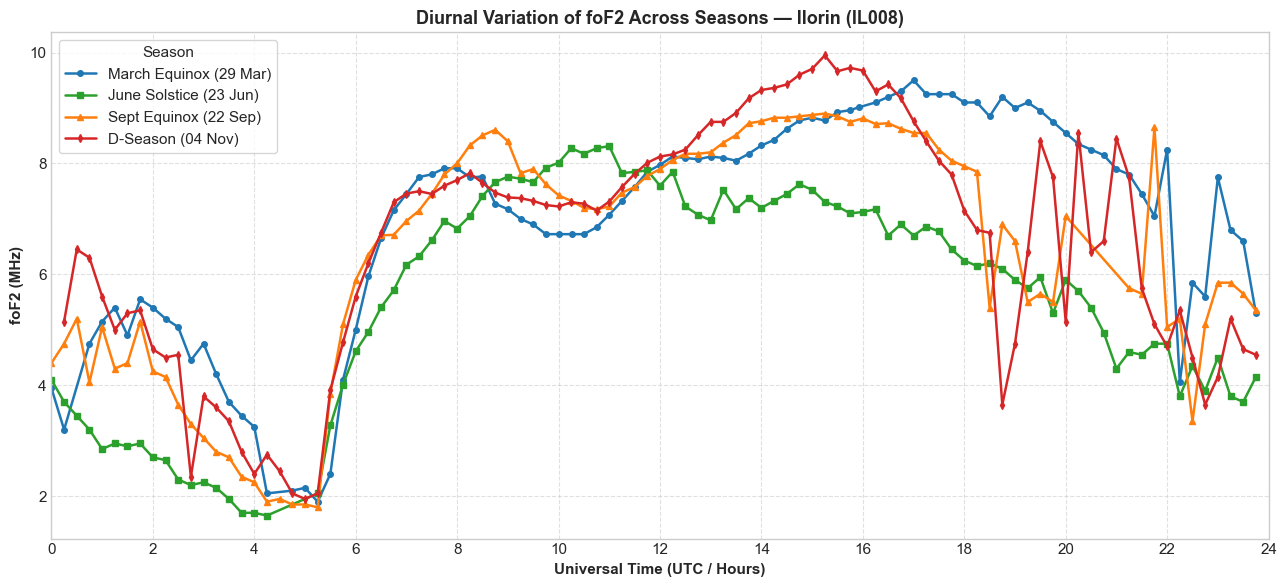

In [13]:
# Step 1: Filter each representative 24-hour day using .between()
march_df = df[df['Time'].between('2010-03-29 00:00', '2010-03-29 23:59')].copy()
june_df  = df[df['Time'].between('2010-06-23 00:00', '2010-06-23 23:59')].copy()
sept_df  = df[df['Time'].between('2010-09-22 00:00', '2010-09-22 23:59')].copy()
nov_df   = df[df['Time'].between('2010-11-04 00:00', '2010-11-04 23:59')].copy()

# Step 2: Plot all four curves directly on a single plot
plt.figure(figsize=(13, 6))

plt.plot(march_df['Hour'], march_df['foF2'], label='March Equinox (29 Mar)', color='tab:blue',   marker='o', markersize=4, lw=1.8)
plt.plot(june_df['Hour'],  june_df['foF2'],  label='June Solstice (23 Jun)',   color='tab:green',  marker='s', markersize=4, lw=1.8)
plt.plot(sept_df['Hour'],  sept_df['foF2'],  label='Sept Equinox (22 Sep)',   color='tab:orange', marker='^', markersize=4, lw=1.8)
plt.plot(nov_df['Hour'],   nov_df['foF2'],   label='D-Season (04 Nov)',       color='tab:red',    marker='d', markersize=4, lw=1.8)

plt.title("Diurnal Variation of foF2 Across Seasons — Ilorin (IL008)", fontsize=13, fontweight='bold')
plt.xlabel("Universal Time (UTC / Hours)", fontsize=11, fontweight='bold')
plt.ylabel("foF2 (MHz)", fontsize=11, fontweight='bold')
plt.xlim(0, 24)
plt.xticks(range(0, 25, 2))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Season", loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

### Approach B (Scalable / Advanced): Dictionary & Loop for 2×1 Stacked Subplots
In scientific computing, using a dictionary and loop keeps your code **DRY (Don't Repeat Yourself)**.
It makes it easy to plot both $foF2$ and $hmF2$ across all seasons simultaneously with consistent styling.

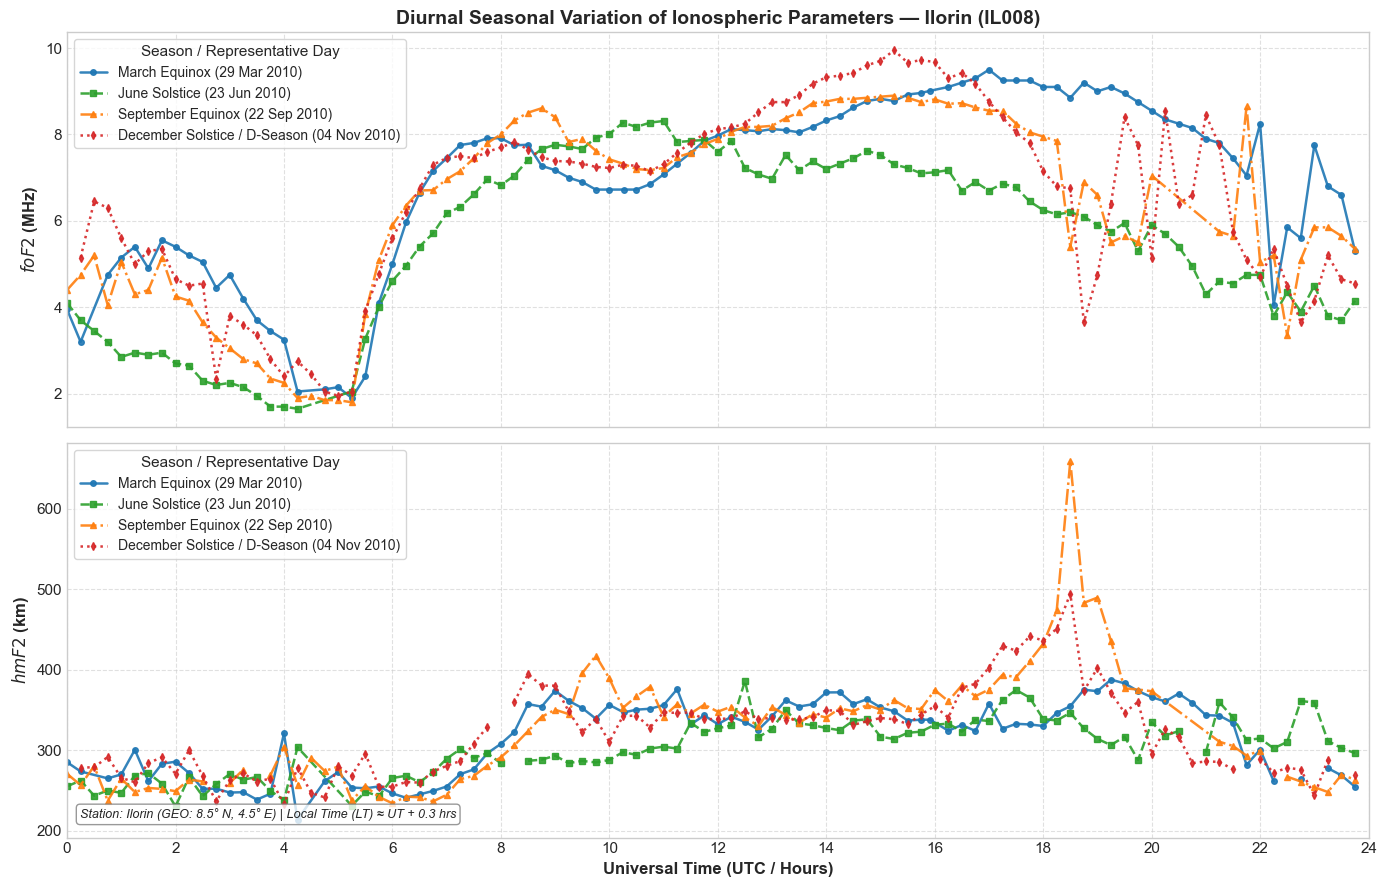

In [14]:
# 1. Define metadata dictionary for each season with start/end timestamps
seasonal_days = {
    'March Equinox (29 Mar 2010)': {
        'start': '2010-03-29 00:00', 'end': '2010-03-29 23:59',
        'color': 'tab:blue', 'marker': 'o', 'linestyle': '-'
    },
    'June Solstice (23 Jun 2010)': {
        'start': '2010-06-23 00:00', 'end': '2010-06-23 23:59',
        'color': 'tab:green', 'marker': 's', 'linestyle': '--'
    },
    'September Equinox (22 Sep 2010)': {
        'start': '2010-09-22 00:00', 'end': '2010-09-22 23:59',
        'color': 'tab:orange', 'marker': '^', 'linestyle': '-.'
    },
    'December Solstice / D-Season (04 Nov 2010)': {
        'start': '2010-11-04 00:00', 'end': '2010-11-04 23:59',
        'color': 'tab:red', 'marker': 'd', 'linestyle': ':'
    }
}

# 2. Create 2x1 figure comparing foF2 and hmF2 diurnal variations
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 9), sharex=True)

for season_name, meta in seasonal_days.items():
    # Filter full 24-hour day using .between()
    day_df = df[df['Time'].between(meta['start'], meta['end'])].copy()
    
    # Top Subplot: Diurnal foF2
    axes[0].plot(
        day_df['Hour'], day_df['foF2'],
        label=season_name,
        color=meta['color'],
        linestyle=meta['linestyle'],
        marker=meta['marker'],
        markersize=4,
        linewidth=1.8,
        alpha=0.9
    )
    
    # Bottom Subplot: Diurnal hmF2
    axes[1].plot(
        day_df['Hour'], day_df['hmF2'],
        label=season_name,
        color=meta['color'],
        linestyle=meta['linestyle'],
        marker=meta['marker'],
        markersize=4,
        linewidth=1.8,
        alpha=0.9
    )

# Formatting Top Subplot (foF2)
axes[0].set_title("Diurnal Seasonal Variation of Ionospheric Parameters — Ilorin (IL008)", fontsize=14, fontweight='bold')
axes[0].set_ylabel(r"$foF2$ (MHz)", fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 24)
axes[0].set_xticks(range(0, 25, 2))
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(title="Season / Representative Day", loc='upper left', frameon=True, fontsize=10)

# Formatting Bottom Subplot (hmF2)
axes[1].set_xlabel("Universal Time (UTC / Hours)", fontsize=12, fontweight='bold')
axes[1].set_ylabel(r"$hmF2$ (km)", fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 24)
axes[1].set_xticks(range(0, 25, 2))
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(title="Season / Representative Day", loc='upper left', frameon=True, fontsize=10)

# Local solar time reference note for Ilorin (Longitude 4.5° E -> LT ≈ UT + 0.3 hrs)
axes[1].annotate(
    "Station: Ilorin (GEO: 8.5° N, 4.5° E) | Local Time (LT) ≈ UT + 0.3 hrs",
    xy=(0.01, 0.05), xycoords='axes fraction',
    fontsize=9, fontstyle='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
)

plt.tight_layout()
plt.show()

In [15]:
# Calculate foF2 in NmF2 inel/m^3 from foF2 in MHz
# Conversion formula: NmF2 ≈ 1.24 × 10¹² × (foF2 in MHz)²

df['NmF2'] = 1.24e12 * (df['foF2'] ** 2)
print(df.head())

                       Time   CS   foF2 foF2_QD   hmF2 hmF2_QD   Hour  \
0 2010-03-26 16:45:00+00:00  100  8.775      //  376.2      //  16.75   
1 2010-03-26 17:00:00+00:00  100  8.806      //  372.6      //  17.00   
2 2010-03-26 17:15:00+00:00   50  6.863      //  288.5      //  17.25   
3 2010-03-26 17:30:00+00:00   75  8.950      //  359.1      //  17.50   
4 2010-03-26 17:45:00+00:00  100  9.050      //  357.9      //  17.75   

           NmF2  
0  9.548078e+13  
1  9.615659e+13  
2  5.840495e+13  
3  9.932710e+13  
4  1.015591e+14  


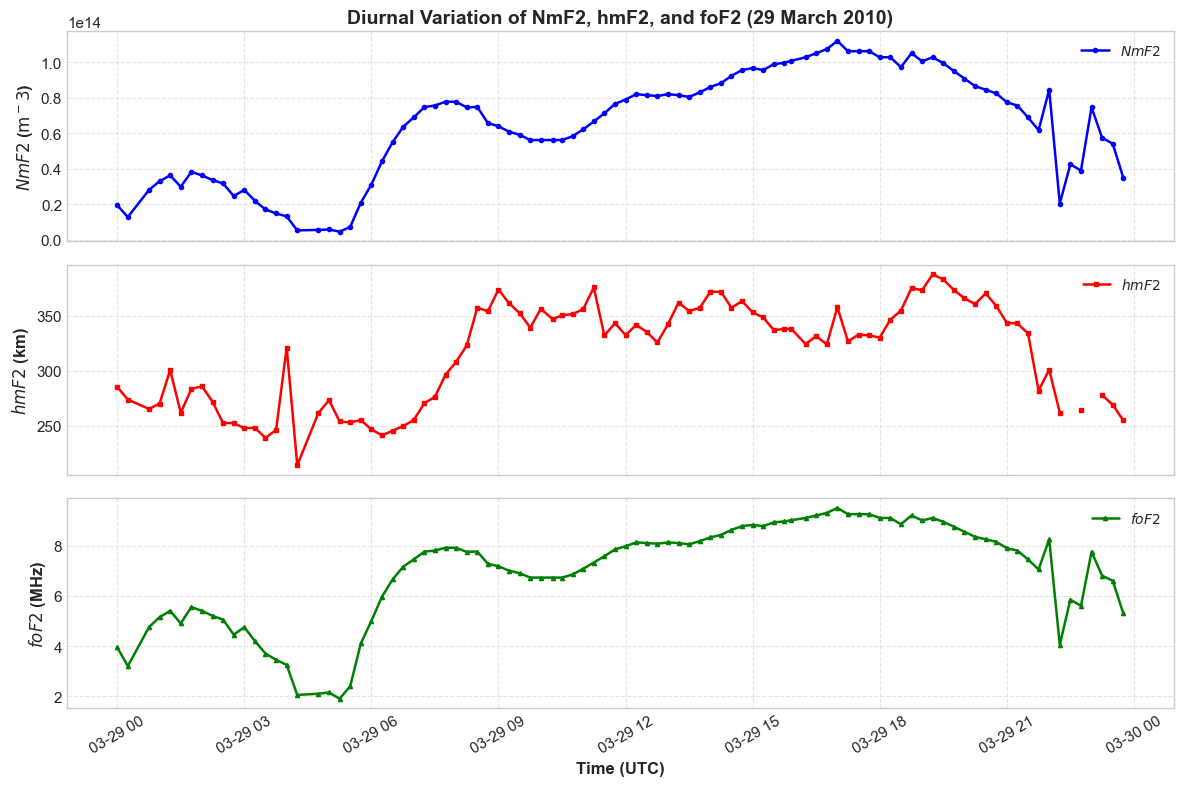


--- Tutorial Script Completed Successfully! ---


In [17]:
# Stacked plot of NmF2, hmF2, and foF2 against time for a particular day
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True)

march_df = df[df['Time'].between('2010-03-29 00:00', '2010-03-29 23:59')].copy()

# 1. Top Subplot: NmF2
axes[0].plot(march_df['Time'], march_df['NmF2'], label=r'$NmF2$', color='blue', linewidth=1.8, marker='o', markersize=3)
axes[0].set_title('Diurnal Variation of NmF2, hmF2, and foF2 (29 March 2010)', fontsize=14, fontweight='bold')
axes[0].set_ylabel(r'$NmF2$ ($\mathrm{m^-3}$)', fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper right', fontsize=10)

# 2. Middle Subplot: hmF2
axes[1].plot(march_df['Time'], march_df['hmF2'], label=r'$hmF2$', color='red', linewidth=1.8, marker='s', markersize=3)
axes[1].set_ylabel(r'$hmF2$ (km)', fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper right', fontsize=10)

# 3. Bottom Subplot: foF2
axes[2].plot(march_df['Time'], march_df['foF2'], label=r'$foF2$', color='green', linewidth=1.8, marker='^', markersize=3)
axes[2].set_xlabel('Time (UTC)', fontsize=12, fontweight='bold')
axes[2].set_ylabel(r'$foF2$ (MHz)', fontsize=12, fontweight='bold')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].legend(loc='upper right', fontsize=10)

# Rotate x-axis labels slightly for better readability
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()





print("\n--- Tutorial Script Completed Successfully! ---")